Task 1: Exploratory Data Analysis (EDA) (2 Marks)
• Loading the dataset
• Displaying important information about the dataset such as dimensions, summary statistics
etc.
• Visualization of the data



Task 2: Data Cleaning & Transformation (2 Marks)
• Outlier detection
• Handling missing values
• Feature Scaling


Task 3: Simple Linear Regression (2 Marks)
• Select one independent variable and build a Simple Linear Regression model using sklearn.
• Split the dataset into training and testing sets.
• Plot the regression line.
• Evaluate the model using R² score, MAE, MSE and RMSE.



Task 4: Multiple Linear Regression (2 Marks)
• Build a Multiple Linear Regression model using multiple features.
• Predict the target variable on the test set.
• Plot the regression line.
• Evaluate the model using R² score, MAE, MSE and RMSE.

Task 1: Exploratory Data Analysis (EDA) 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [9]:
# Load dataset

df = pd.read_excel(r"C:\Users\Anu A\Desktop\ML_LAB\Concrete_Data.xls")

In [10]:
# Display first rows
print(df.head())


   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mixture)  \
0      

In [11]:
# Dataset shape
print("Dimensions:", df.shape)

Dimensions: (1030, 9)


In [12]:
# Dataset information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)        1030 

In [13]:
# Summary statistics
print(df.describe())

       Cement (component 1)(kg in a m^3 mixture)  \
count                                1030.000000   
mean                                  281.165631   
std                                   104.507142   
min                                   102.000000   
25%                                   192.375000   
50%                                   272.900000   
75%                                   350.000000   
max                                   540.000000   

       Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
count                                        1030.000000       
mean                                           73.895485       
std                                            86.279104       
min                                             0.000000       
25%                                             0.000000       
50%                                            22.000000       
75%                                           142.950000       
max                

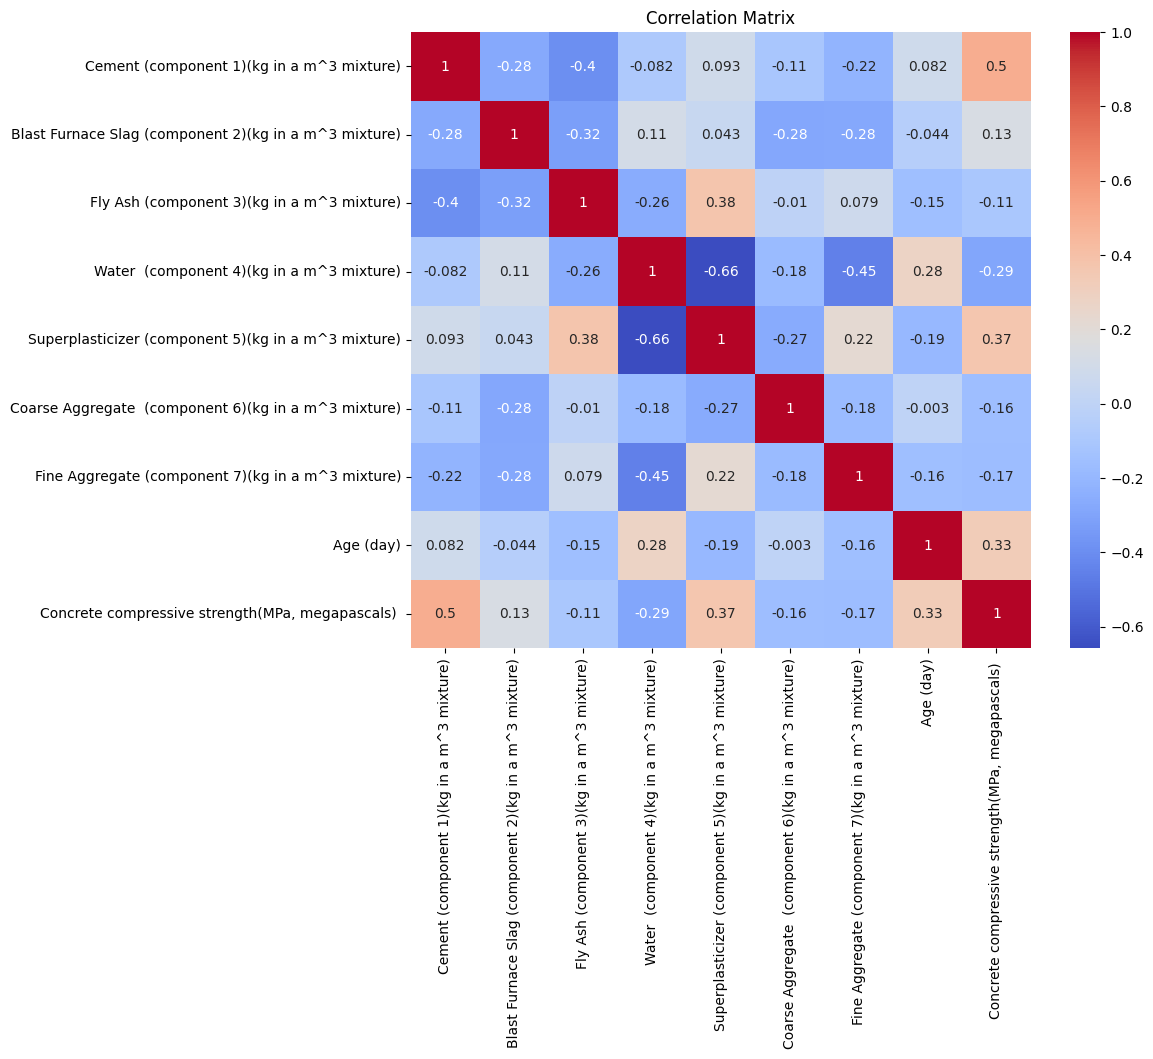

In [14]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()



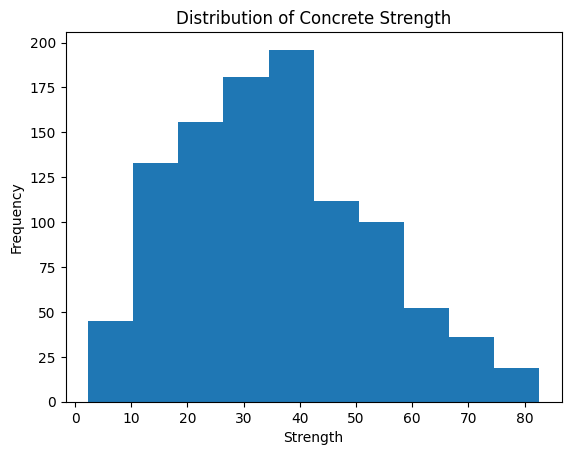

In [15]:

# Histogram of target variable
plt.hist(df['Concrete compressive strength(MPa, megapascals) '])
plt.title("Distribution of Concrete Strength")
plt.xlabel("Strength")
plt.ylabel("Frequency")
plt.show()



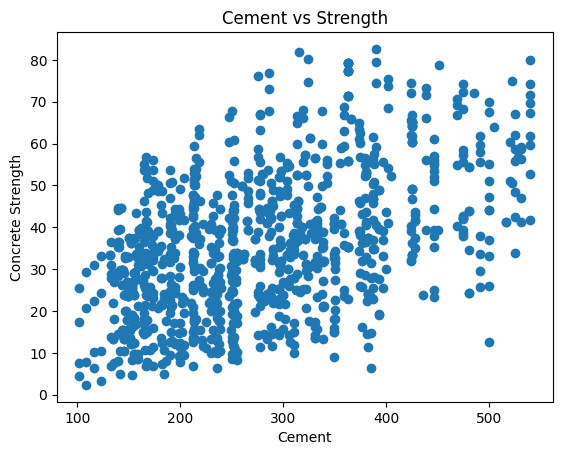

In [16]:


# Scatter plot
plt.scatter(df['Cement (component 1)(kg in a m^3 mixture)'], 
            df['Concrete compressive strength(MPa, megapascals) '])
plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Cement vs Strength")
plt.show()

Task 2: Data Cleaning & Transformation

In [17]:
#handling missing values
print(df.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


Dataset description says no missing values, but this confirms it.

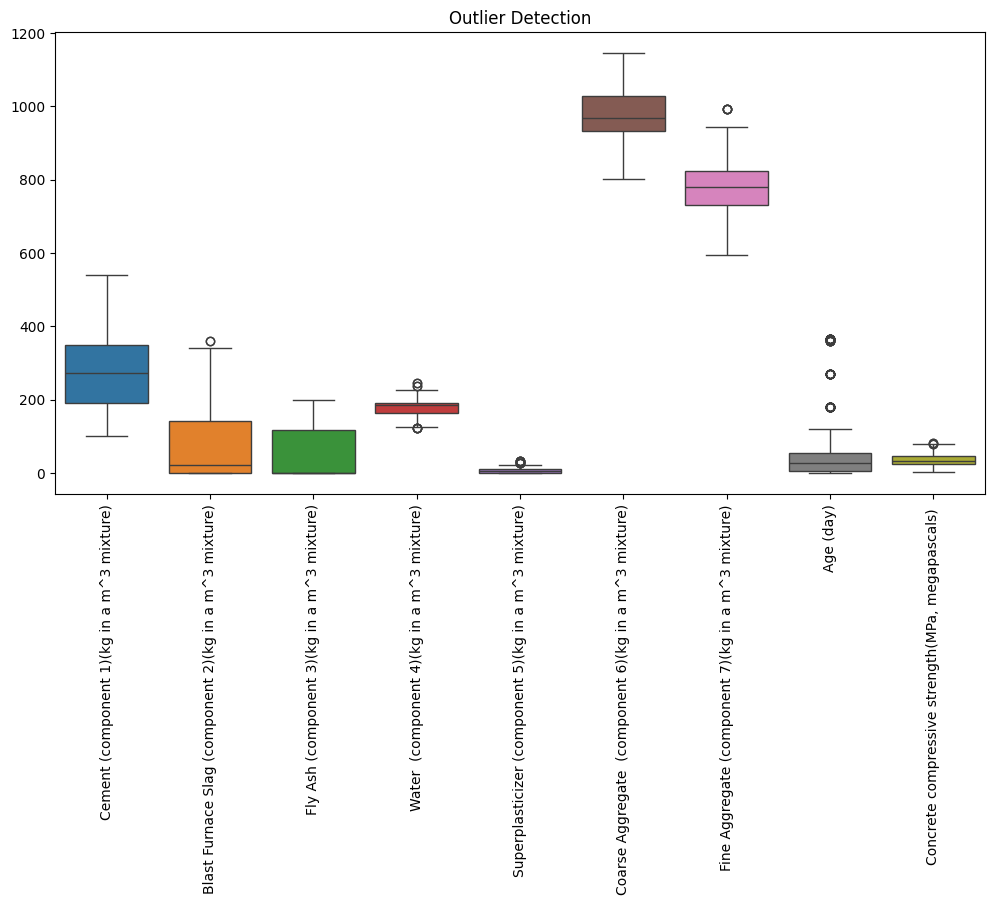

In [19]:
#Outlier Detection (Boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [27]:
#outlier dectection
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print("Number of outliers in each column:")
print(outliers.sum())

Number of outliers in each column:
Cement (component 1)(kg in a m^3 mixture)                 0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)     2
Fly Ash (component 3)(kg in a m^3 mixture)                0
Water  (component 4)(kg in a m^3 mixture)                 9
Superplasticizer (component 5)(kg in a m^3 mixture)      10
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         5
Age (day)                                                59
Concrete compressive strength(MPa, megapascals)           4
dtype: int64


Outliers were detected using boxplots and the IQR method. Since the dataset represents real laboratory measurements, the detected outliers were considered valid observations and were not removed.

In [20]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

X = df.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y = df['Concrete compressive strength(MPa, megapascals) ']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Task 3: Simple Linear Regression 

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

X_simple = df[['Cement (component 1)(kg in a m^3 mixture)']]
y = df['Concrete compressive strength(MPa, megapascals) ']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

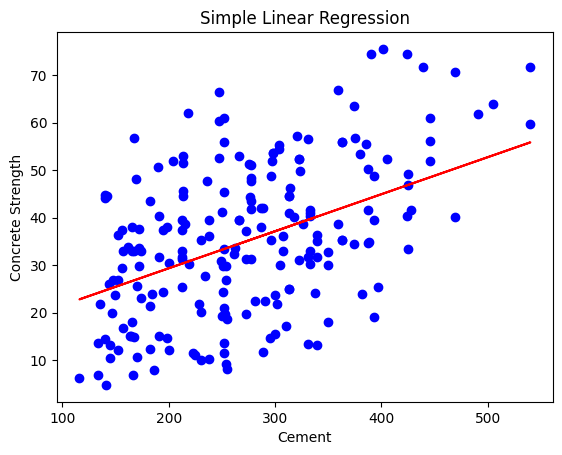

In [22]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Cement")
plt.ylabel("Concrete Strength")
plt.title("Simple Linear Regression")
plt.show()

In [23]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.25183140674244187
MAE: 11.555820769998833
MSE: 192.78889718821986
RMSE: 13.884844154264744


Task 4: Multiple Linear Regression

In [24]:
X = df.drop('Concrete compressive strength(MPa, megapascals) ', axis=1)
y = df['Concrete compressive strength(MPa, megapascals) ']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

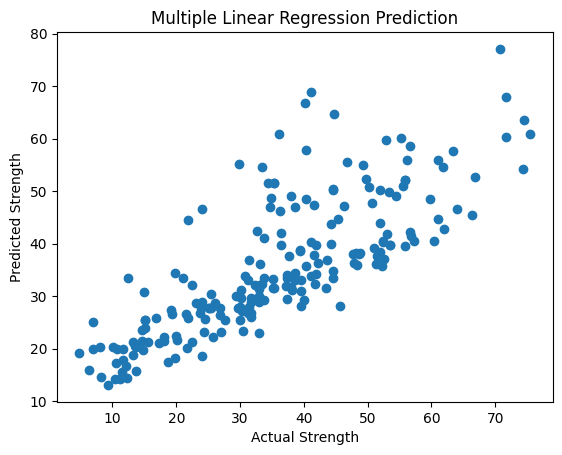

In [25]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Multiple Linear Regression Prediction")
plt.show()

In [26]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6275416055429021
MAE: 7.745392872421344
MSE: 95.97548435337706
RMSE: 9.796707832398447
